In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json

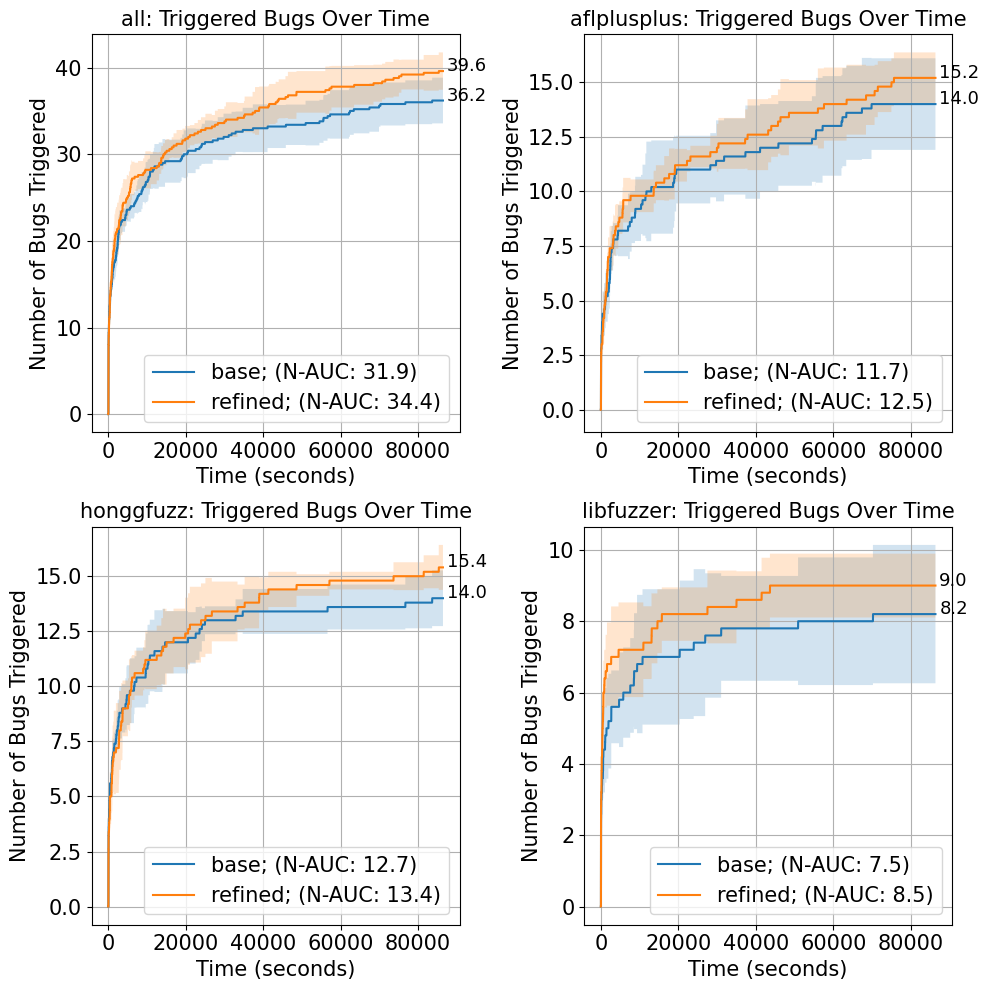

In [ ]:
individual_triggered = dict()
for setting in ["base", "refined"]:
    result = json.load(open(f"../../result/fuzzing_magma/magma_workdir_{setting}.json"))["results"]

    individual_triggered[setting] = dict()
    for fuzzer in result:
        individual_triggered[setting][fuzzer] = dict()
        for target in result[fuzzer]:
            for program in result[fuzzer][target]:
                for run in result[fuzzer][target][program]:
                    if run not in individual_triggered[setting][fuzzer]:
                        individual_triggered[setting][fuzzer][run] = dict()
                    for triggered_bug in result[fuzzer][target][program][run]["triggered"]:
                        if triggered_bug not in individual_triggered[setting][fuzzer][run]:
                            individual_triggered[setting][fuzzer][run][triggered_bug] = result[fuzzer][target][program][run]["triggered"][triggered_bug]
                        else:
                            individual_triggered[setting][fuzzer][run][triggered_bug] = min(
                                individual_triggered[setting][fuzzer][run][triggered_bug], 
                                result[fuzzer][target][program][run]["triggered"][triggered_bug]
                                )
    for fuzzer in individual_triggered[setting]:
        for run in individual_triggered[setting][fuzzer]:
            individual_triggered[setting][fuzzer][run] = sorted(list(individual_triggered[setting][fuzzer][run].values()))
            temp_list = np.zeros(24 * 60 * 60 + 1)
            temp_list[individual_triggered[setting][fuzzer][run]] = 1
            temp_list = np.cumsum(temp_list).astype(int)
            individual_triggered[setting][fuzzer][run] = temp_list
        individual_triggered[setting][fuzzer] = np.stack([individual_triggered[setting][fuzzer][key] for key in sorted(individual_triggered[setting][fuzzer].keys())])

    individual_triggered[setting]["all"] = np.sum(np.stack(list(individual_triggered[setting].values())), axis=0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for idx, fuzzer in enumerate(["all", "aflplusplus", "honggfuzz", "libfuzzer"]):
    for setting in individual_triggered.keys():
        auc = np.trapz(
            individual_triggered[setting][fuzzer].mean(axis=0),
            dx=1
        ) / (24 * 60 * 60)
        axes[idx//2][idx%2].plot(
            individual_triggered[setting][fuzzer].mean(axis=0),
            label=f"{setting}; (N-AUC: {auc:.1f})",
        )
        axes[idx//2][idx%2].annotate(
            f"{individual_triggered[setting][fuzzer].mean(axis=0)[-1]:.1f}",
            xy=(len(individual_triggered[setting][fuzzer].mean(axis=0)) - 1, individual_triggered[setting][fuzzer].mean(axis=0)[-1]),
            xytext=(len(individual_triggered[setting][fuzzer].mean(axis=0) - 1) + 1000, individual_triggered[setting][fuzzer].mean(axis=0)[-1]),
            fontsize=13,
        )
        axes[idx//2][idx%2].fill_between(
            np.arange(0, individual_triggered[setting][fuzzer].shape[1]),
            individual_triggered[setting][fuzzer].mean(axis=0) - np.std(individual_triggered[setting][fuzzer], axis=0),
            individual_triggered[setting][fuzzer].mean(axis=0) + np.std(individual_triggered[setting][fuzzer], axis=0),
            alpha=0.2
        )
    axes[idx//2][idx%2].grid()
    axes[idx//2][idx%2].legend(prop={'size': 15}, loc="lower right")
    axes[idx//2][idx%2].set_xlabel("Time (seconds)", fontsize=15)
    axes[idx//2][idx%2].set_ylabel("Number of Bugs Triggered", fontsize=15)
    axes[idx//2][idx%2].tick_params(axis='both', which='major', labelsize=15)
    axes[idx//2][idx%2].set_title(f"{fuzzer}: Triggered Bugs Over Time", fontsize=15)

fig.tight_layout()
plt.show()